##    **ENERGY ANALYTICS AND IT'S APPLICATION**

**1. Aim :** The aim of this project is using machine learning model to predict peak electricity demand.


**2. Problem Statement :** Electricity demand varies significantly due to weather conditions, seasonal changes, and human activities. Predicting peak demand is challenging but essential for efficient energy management.

**3. Dataset Description :**  The dataset used in this project contains historical energy consumption and weather-related variables.
Key features include :
   
i.   Temperature (average, minimum, maximum)

ii.  surface_pressure

iii. wind_speed(average, minimum, maximum)

iv.  precipitation

v.   demand

vi.  Derived features such as temperature squared and temperature range

vii.  Cooling Degree Days (CDD) and Heating Degree Days (HDD) 

viii.Date and time-related variables 

**4. Methodology :**

The project follows a structured approach :

i.   Data Collection 

ii.  Data Cleaning

iii. Exploratory Data Analysis (EDA)

iv.  Feature Engineering

v.   Model Building (Random Forest, XGBoost, catboost, LightGBM) 

vi.  Model Evaluation (RMSE, R² Score)
  
vii. Prediction of Peak Demand 

## IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

##  LOADING DATASET

In [2]:
df=pd.read_csv("final_dataset_v2.csv")
df.head()

,date_1,day,month,year,temp2(c),temp2_max(c),temp2_min(c),temp2_ave(c),suface_pressure(pa),wind_speed50_max(m/s),wind_speed50_min(m/s),wind_speed50_ave(m/s),prectotcorr,total_demand(mw),date_2,max_generation(mw)
0,01-01-18,1,1,2018,19.11,24.48,13.78,19.130,101.08,5.05,0.23,2.640,0.00,8000.0,01-01-18,7651.0
1,02-01-18,2,1,2018,18.24,23.16,15.28,19.220,100.94,6.20,1.59,3.895,0.01,7900.0,02-01-18,7782.0
2,03-01-18,3,1,2018,15.78,22.65,11.52,17.085,101.12,6.96,3.64,5.300,0.17,7900.0,03-01-18,7707.0
3,04-01-18,4,1,2018,13.78,20.32,8.19,14.255,101.34,5.91,1.54,3.725,0.34,8000.0,04-01-18,7715.0
4,05-01-18,5,1,2018,13.87,20.79,8.24,14.515,101.17,6.02,3.09,4.555,0.00,7200.0,05-01-18,6926.0


## DATA CLEANING

In [3]:
df.columns

Index(['date_1', 'day', 'month', 'year', 'temp2(c)', 'temp2_max(c)',
       'temp2_min(c)', 'temp2_ave(c)', 'suface_pressure(pa)',
       'wind_speed50_max(m/s)', 'wind_speed50_min(m/s)',
       'wind_speed50_ave(m/s)', 'prectotcorr', 'total_demand(mw)', 'date_2',
       'max_generation(mw)'],
      dtype='object')

In [4]:
df.shape

(1946, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1946 entries, 0 to 1945
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_1                 1946 non-null   object 
 1   day                    1946 non-null   int64  
 2   month                  1946 non-null   int64  
 3   year                   1946 non-null   int64  
 4   temp2(c)               1946 non-null   float64
 5   temp2_max(c)           1946 non-null   float64
 6   temp2_min(c)           1946 non-null   float64
 7   temp2_ave(c)           1946 non-null   float64
 8   suface_pressure(pa)    1946 non-null   float64
 9   wind_speed50_max(m/s)  1946 non-null   float64
 10  wind_speed50_min(m/s)  1946 non-null   float64
 11  wind_speed50_ave(m/s)  1946 non-null   float64
 12  prectotcorr            1946 non-null   float64
 13  total_demand(mw)       1921 non-null   float64
 14  date_2                 1946 non-null   object 
 15  max_

In [6]:
df.isnull().sum()

date_1                    0
day                       0
month                     0
year                      0
temp2(c)                  0
temp2_max(c)              0
temp2_min(c)              0
temp2_ave(c)              0
suface_pressure(pa)       0
wind_speed50_max(m/s)     0
wind_speed50_min(m/s)     0
wind_speed50_ave(m/s)     0
prectotcorr               0
total_demand(mw)         25
date_2                    0
max_generation(mw)       35
dtype: int64

In [7]:
# Droping null values

df=df.dropna()
df.isnull().sum()



date_1                   0
day                      0
month                    0
year                     0
temp2(c)                 0
temp2_max(c)             0
temp2_min(c)             0
temp2_ave(c)             0
suface_pressure(pa)      0
wind_speed50_max(m/s)    0
wind_speed50_min(m/s)    0
wind_speed50_ave(m/s)    0
prectotcorr              0
total_demand(mw)         0
date_2                   0
max_generation(mw)       0
dtype: int64

In [8]:
# checking duplicate values
df.duplicated().sum()


0

In [9]:
df.duplicated().any()


False

In [10]:
# dropping unnecessary columns
df.drop(columns=['date_2','max_generation(mw)'],axis=1,inplace=True)

In [11]:
# Again checking columns
df.columns

Index(['date_1', 'day', 'month', 'year', 'temp2(c)', 'temp2_max(c)',
       'temp2_min(c)', 'temp2_ave(c)', 'suface_pressure(pa)',
       'wind_speed50_max(m/s)', 'wind_speed50_min(m/s)',
       'wind_speed50_ave(m/s)', 'prectotcorr', 'total_demand(mw)'],
      dtype='object')

In [12]:
# changing date from object to datetime

df['date_1'] = pd.to_datetime(df['date_1'], errors='coerce')


In [13]:
df['date_1'].dtypes

dtype('<M8[ns]')

In [14]:
# Outlier handling

cols = [
'temp2(c)','temp2_max(c)','temp2_min(c)','temp2_ave(c)',
'suface_pressure(pa)',
'wind_speed50_max(m/s)','wind_speed50_min(m/s)','wind_speed50_ave(m/s)',
'prectotcorr','total_demand(mw)'
]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    median = df[col].median()

    df.loc[
        (df[col] < lower) | (df[col] > upper),
        col
    ] = median

##  EDA

In [15]:
df.describe()

,date_1,day,month,year,temp2(c),temp2_max(c),temp2_min(c),temp2_ave(c),suface_pressure(pa),wind_speed50_max(m/s),wind_speed50_min(m/s),wind_speed50_ave(m/s),prectotcorr,total_demand(mw)
count,1894,1894.000000,1894.000000,1894.00000,1894.000000,1894.000000,1894.000000,1894.000000,1894.000000,1894.000000,1894.000000,1894.00000,1894.000000,1894.000000
mean,2020-09-02 04:19:15.649419264,15.718585,6.247624,2020.18585,25.352962,30.118949,21.090924,25.632455,100.718543,5.697207,2.304113,4.00746,3.420203,10418.921859
min,2018-01-01 00:00:00,1.000000,1.000000,2018.00000,12.800000,19.810000,6.430000,13.040000,99.030000,1.470000,0.020000,0.78000,0.000000,5372.000000
25%,2019-05-02 06:00:00,8.000000,3.000000,2019.00000,21.682500,27.420000,16.280000,21.890000,100.260000,4.410000,0.940000,2.79000,0.000000,9000.000000
50%,2020-08-31 12:00:00,16.000000,6.000000,2020.00000,27.505000,30.680000,23.330000,27.687500,100.750000,5.720000,1.890000,3.82500,1.212500,10341.000000
75%,2021-12-27 18:00:00,23.000000,9.000000,2021.00000,28.730000,32.350000,26.017500,28.980000,101.197500,6.850000,3.427500,5.10000,5.150000,11797.750000
max,2023-12-04 00:00:00,31.000000,12.000000,2023.00000,34.880000,40.020000,27.940000,35.470000,101.860000,10.840000,7.200000,8.63500,20.530000,15500.000000
std,NaN,8.798712,3.481964,1.54977,4.674327,4.069849,5.630911,4.610024,0.567098,1.723083,1.646283,1.55739,5.044917,1676.036740


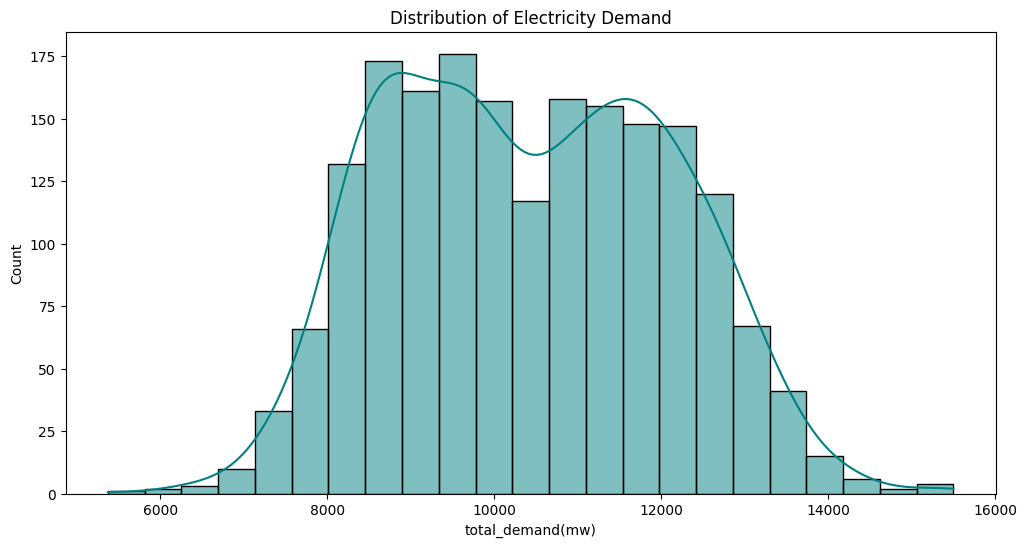

In [16]:
# Checking the Demand distribution 
plt.figure(figsize=(12,6))
sns.histplot(df['total_demand(mw)'], kde=True, color='teal')
plt.title('Distribution of Electricity Demand')
plt.show()


<Axes: xlabel='total_demand(mw)', ylabel='Density'>

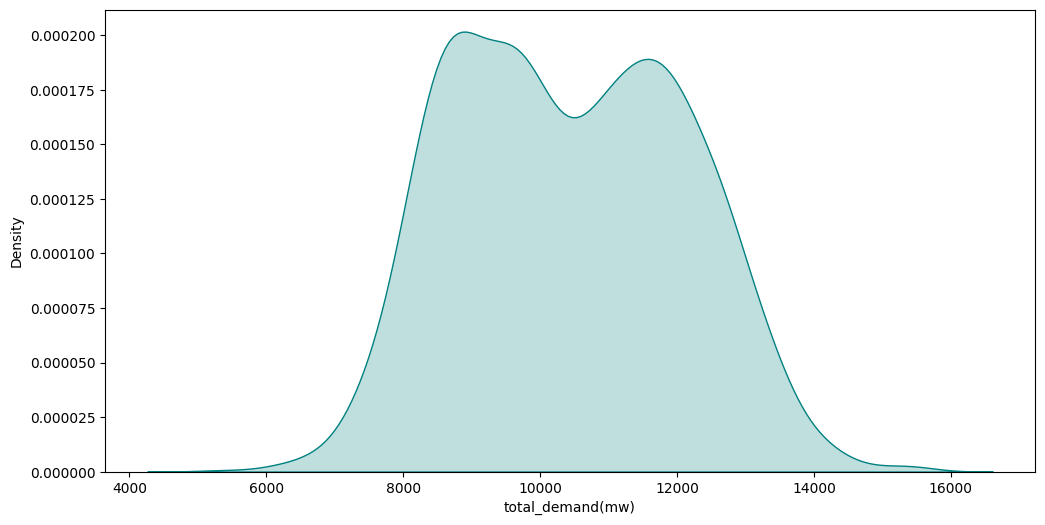

In [17]:
# Demand density graph
plt.figure(figsize=(12,6))
sns.kdeplot(df['total_demand(mw)'],fill=True,color='teal')

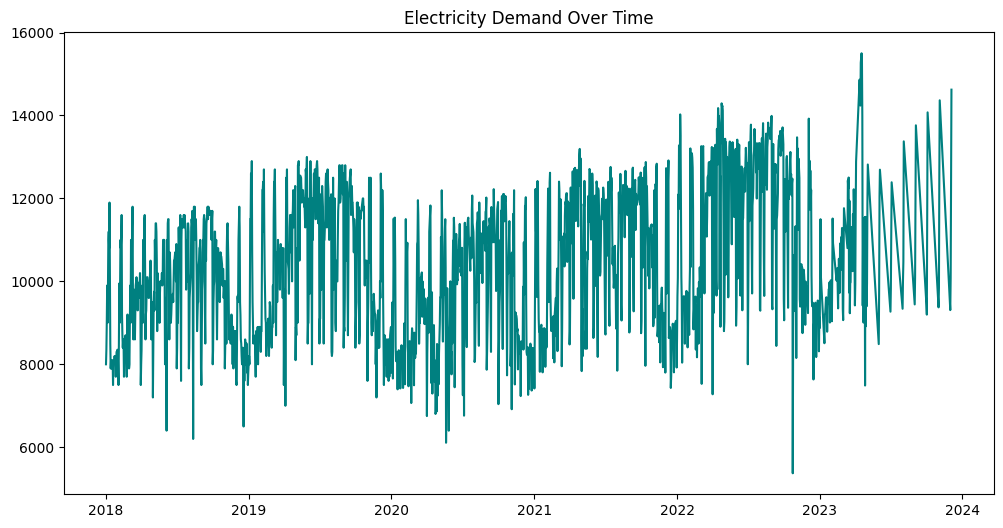

In [18]:
# Sort the dataframe by date
df = df.sort_values('date_1')

# Now plot
plt.figure(figsize=(12,6))
plt.plot(df['date_1'], df['total_demand(mw)'],color='teal')
plt.title("Electricity Demand Over Time")
plt.show()

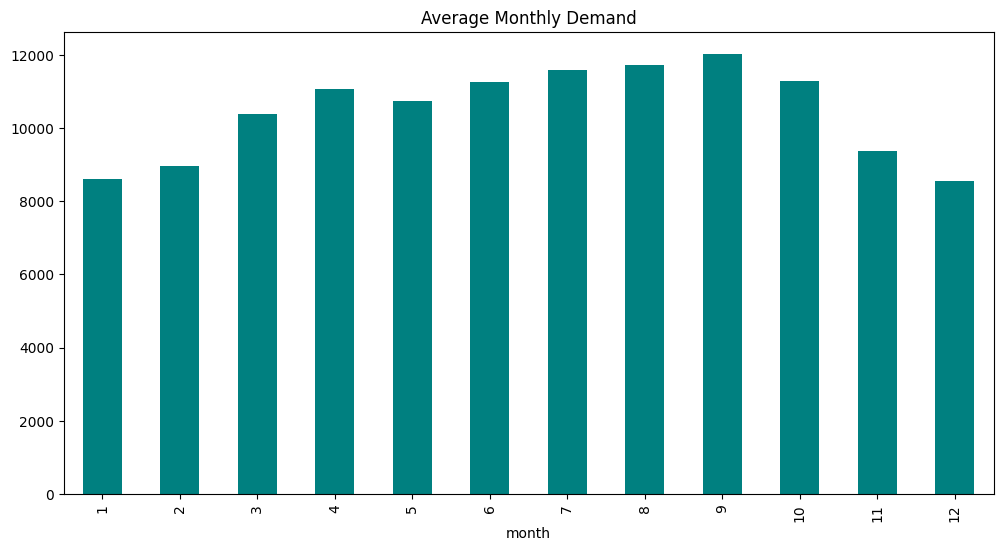

In [19]:
# Average Monthly Deamnd Trend 
plt.figure(figsize=(12,6))
df.groupby('month')['total_demand(mw)'].mean().plot(kind='bar',color='teal')
plt.title("Average Monthly Demand")
plt.show()

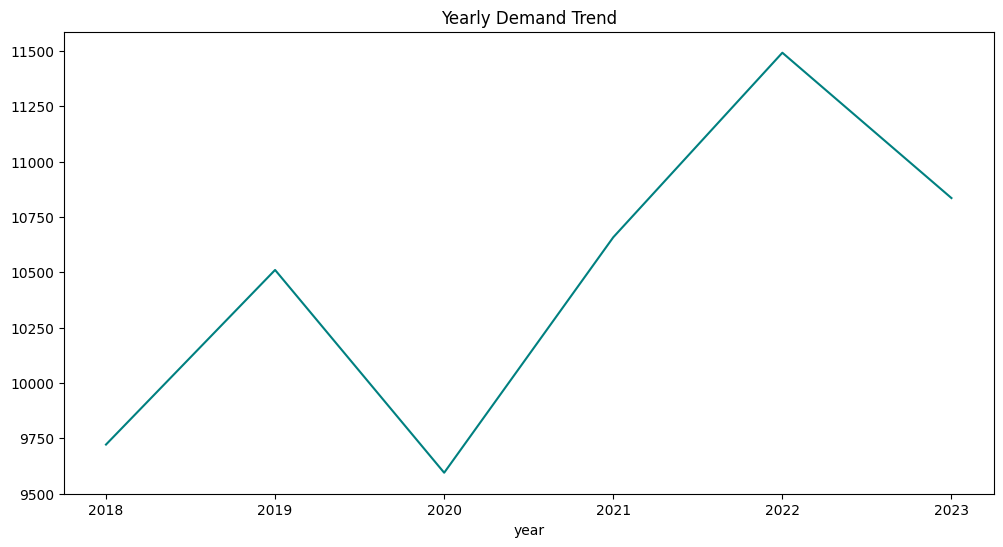

In [20]:
#  Average Yearly Demand Trend

plt.figure(figsize=(12,6))
df.groupby('year')['total_demand(mw)'].mean().plot(color='teal')
plt.title("Yearly Demand Trend")
plt.show()

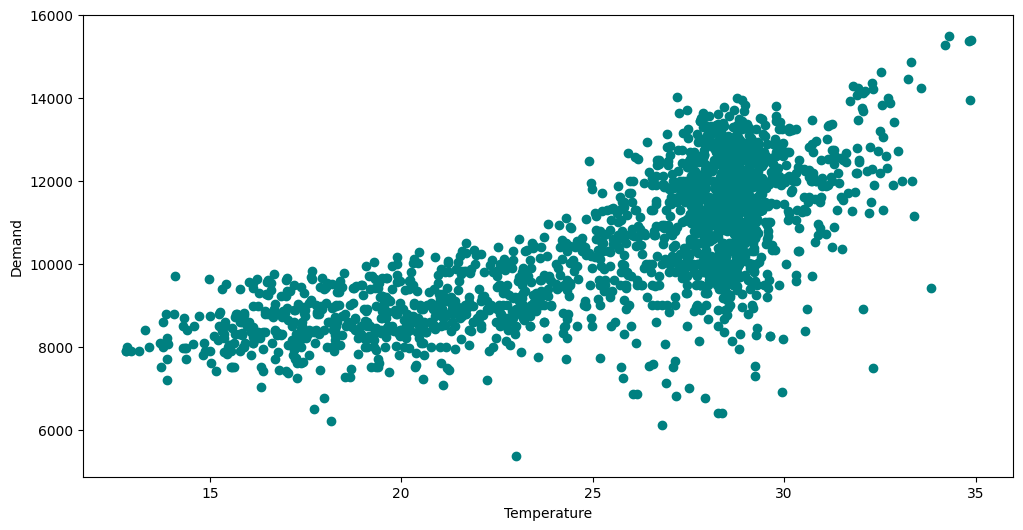

In [21]:
# Correlation b/w Temperature vs Demand
plt.figure(figsize=(12,6))
plt.scatter(df['temp2(c)'], df['total_demand(mw)'], color='teal')
plt.xlabel("Temperature")
plt.ylabel("Demand")
plt.show()

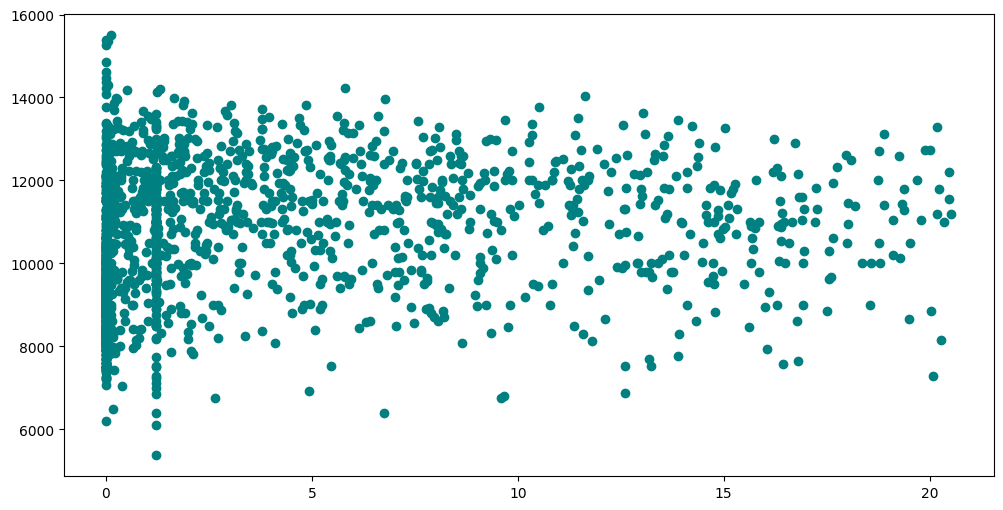

In [22]:
# Correlation b/w Precipitation vs Demand
plt.figure(figsize=(12,6))
plt.scatter(df['prectotcorr'], df['total_demand(mw)'], color='teal')
plt.show()

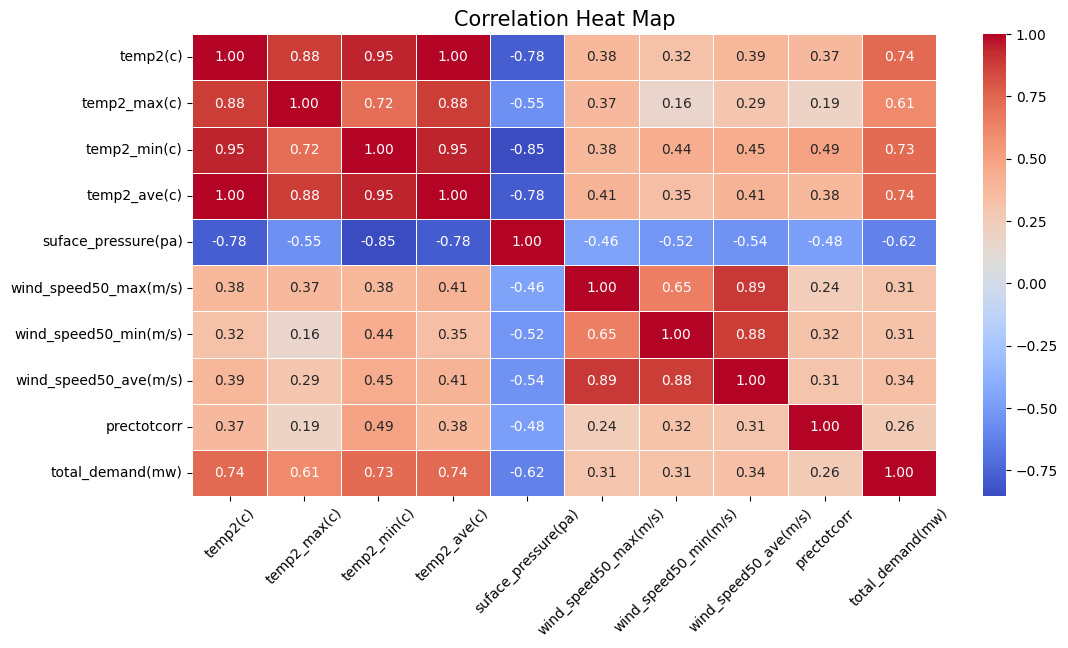

In [23]:
# Correlation heat Map

df_num = df.select_dtypes(include=['int64', 'float64']).drop(columns=['day', 'month', 'year'], errors='ignore')
plt.figure(figsize=(12,6))
sns.heatmap(
    df_num.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heat Map", fontsize=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

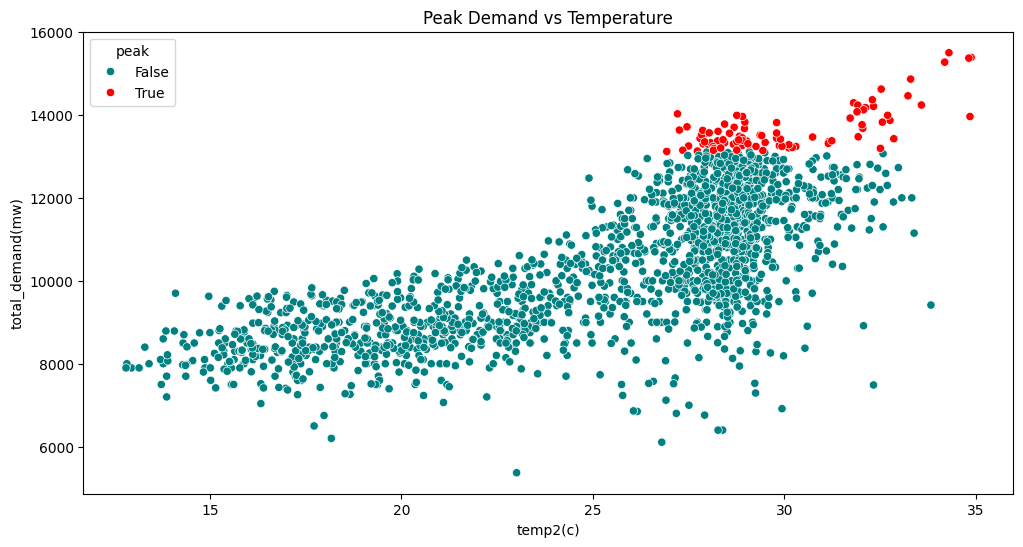

In [24]:
# checking what was peak demand when temperature is relativly High
plt.figure(figsize=(12,6))
threshold = df['total_demand(mw)'].quantile(0.95)
df['peak'] = df['total_demand(mw)'] > threshold
sns.scatterplot(x=df['temp2(c)'], y=df['total_demand(mw)'], hue=df['peak'], palette={False: 'teal', True: 'red'})
plt.title("Peak Demand vs Temperature")
plt.show()

## FEATURE ENGINEERING

In [25]:
# Sorting by time to avoid leakage
df = df.sort_values('date_1').reset_index(drop=True)

In [26]:
# Temperature-Based Features
df['temp_sq'] = df['temp2(c)'] ** 2
df['temp_cube'] = df['temp2(c)'] ** 3
df['temp_range'] = df['temp2_max(c)'] - df['temp2_min(c)']


In [27]:
# Adding Cooling & Heating Degree Days
df['CDD'] = (df['temp2(c)'] - 18).clip(lower=0)
df['HDD'] = (18 - df['temp2(c)']).clip(lower=0)

In [28]:
# Adding Lags features
df['lag_1'] = df['total_demand(mw)'].shift(1)
df['lag_2'] = df['total_demand(mw)'].shift(2)
df['lag_7'] = df['total_demand(mw)'].shift(7)

In [29]:
# Adding rolling features
df['rolling_mean_3'] = df['total_demand(mw)'].rolling(3).mean()
df['rolling_max_7'] = df['total_demand(mw)'].rolling(7).max()

In [30]:
# Adding time features 
df['day'] = df['date_1'].dt.day
df['month'] = df['date_1'].dt.month
df['weekday'] = df['date_1'].dt.weekday
df['weekend'] = df['weekday'].isin([5,6]).astype(int)

In [31]:
# Dropping NaN values after feature engineering
df_clean = df.dropna()

## MODELING

In [32]:
# Train test split
df = df.sort_values('date_1')

train = df[df['date_1'] < '2023-01-01']
test = df[df['date_1'] >= '2023-01-01']

In [33]:
# Features & Target
drop_cols = ['total_demand(mw)', 'date_1']

X_train = train.drop(columns=drop_cols)
y_train = train['total_demand(mw)']

X_test = test.drop(columns=drop_cols)
y_test = test['total_demand(mw)' ]




In [34]:
# Models
rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42)

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

lgb = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6
)

cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    verbose=0
)


In [35]:
#Train
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
lgb.fit(X_train, y_train)
cat.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001520 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4661
[LightGBM] [Info] Number of data points in the train set: 1775, number of used features: 25
[LightGBM] [Info] Start training from score 10390.989859
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

CatBoostRegressor(depth=6, iterations=1000, learning_rate=0.03, loss_function='RMSE', verbose=0)

In [36]:
# Prediction
pred_rf = rf.predict(X_test)
pred_xgb = xgb.predict(X_test)
pred_lgb = lgb.predict(X_test)
pred_cat = cat.predict(X_test)

In [37]:
# Evaluation Function

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


print("RF:", evaluate(y_test, pred_rf))
print("XGB:", evaluate(y_test, pred_xgb))
print("LGB:", evaluate(y_test, pred_lgb))
print("CAT:", evaluate(y_test, pred_cat))

RF: (467.4722466728823, 624.1798973051413, 0.8648725153325378)
XGB: (395.8027836134454, 586.0677158958846, 0.8808703859322777)
LGB: (343.63830164681724, 546.9483673774145, 0.8962431451937851)
CAT: (418.0901438910568, 657.1865673166828, 0.8502035594390185)


In [38]:
# Ensemble
final_pred = (pred_rf + pred_xgb + pred_lgb + pred_cat) / 4

mae_ens, rmse_ens, r2_ens = evaluate(y_test, final_pred)
print("ENSEMBLE:", mae_ens, rmse_ens, r2_ens)

ENSEMBLE: 387.34742763840546 581.2026831713622 0.8828400010819183


In [39]:
# Result Table

results = pd.DataFrame({
    "Model": ["RF", "XGB", "LGB", "CAT", "ENSEMBLE"],
    "R2": [
        evaluate(y_test, pred_rf)[2],
        evaluate(y_test, pred_xgb)[2],
        evaluate(y_test, pred_lgb)[2],
        evaluate(y_test, pred_cat)[2],
        r2_ens
    ]
})

print(results.sort_values("R2", ascending=False))

      Model        R2
2       LGB  0.896243
4  ENSEMBLE  0.882840
1       XGB  0.880870
0        RF  0.864873
3       CAT  0.850204


In [40]:
# Peak Demand Detection

threshold = y_test.quantile(0.80)
print("Peak Threshold:", threshold)

actual_peak = y_test > threshold
pred_peak = final_pred > np.percentile(final_pred, 80)
print("Actual Peaks:", actual_peak.sum())
print("Predicted Peaks:", pred_peak.sum())





Peak Threshold: 11991.2
Actual Peaks: 24
Predicted Peaks: 24


In [41]:
from sklearn.metrics import classification_report, confusion_matrix

print('Classification Report :\n','.........................\n', classification_report(actual_peak, pred_peak))
print('Confusion Matrix :\n','............................\n' , confusion_matrix(actual_peak, pred_peak))

Classification Report :
 .........................
               precision    recall  f1-score   support

       False       0.99      0.99      0.99        95
        True       0.96      0.96      0.96        24

    accuracy                           0.98       119
   macro avg       0.97      0.97      0.97       119
weighted avg       0.98      0.98      0.98       119

Confusion Matrix :
 ............................
 [[94  1]
 [ 1 23]]


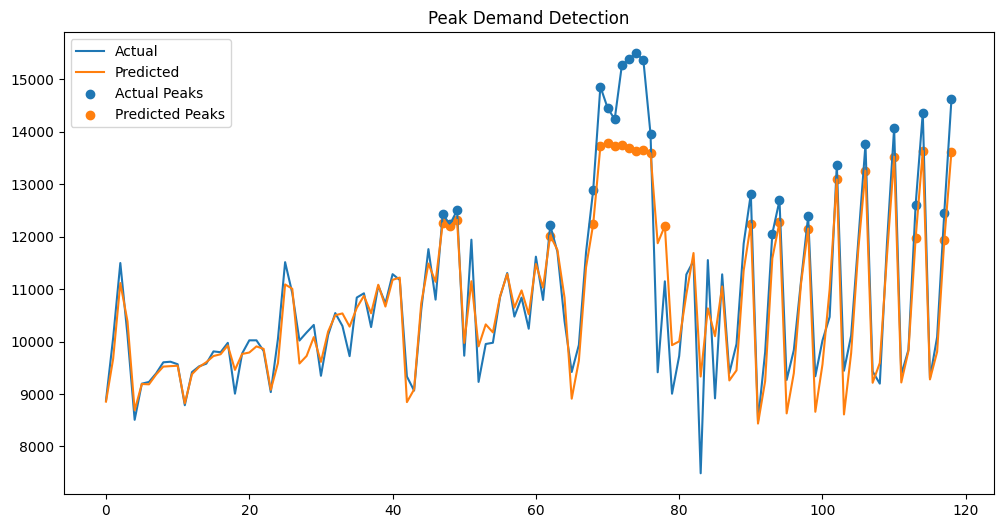

In [42]:
# Visualization

plt.figure(figsize=(12,6))

x = range(len(y_test))

plt.plot(x, y_test.values, label="Actual")
plt.plot(x, final_pred, label="Predicted")

plt.scatter(x, y_test.where(actual_peak), label="Actual Peaks")
plt.scatter(x, pd.Series(final_pred).where(pred_peak), label="Predicted Peaks")

plt.legend()
plt.title("Peak Demand Detection")
plt.show()
